# Brain Tumor MRI — Anomaly Detection (Autoencoder + Mahalanobis Distance)

**Objective.** Train a model to recognize what a glioma scan "normally"
looks like, using only glioma images, then test whether it can flag
scans from *other* tumor types as anomalous relative to that learned
distribution — a semi-supervised alternative to directly classifying all
three tumor types.

**Dataset.** Same 6,056-image dataset used elsewhere in this project
(`brain_glioma`, `brain_menin`, `brain_tumor`), but only `brain_glioma`
is used for training.

**Approach.**
1. Resize glioma images to 128×128 grayscale.
2. Train a small convolutional autoencoder to reconstruct glioma images.
3. Extract the trained encoder's latent representation, reduce it with PCA.
4. Fit a Gaussian (mean + covariance) over the training latent space.
5. Score new images by their Mahalanobis distance to that distribution.
6. Flag images beyond the 90th-percentile training distance as anomalies.

**Fixes applied vs. the original script.** The original evaluated on the
same root folder used for training, so the "test" set silently included
the exact glioma images the model had already seen — this notebook
holds out 20% of glioma images *before* training and never shows them to
the autoencoder. Paths are also now portable (resolved relative to this
notebook) instead of hardcoded to one machine, and a fixed seed makes the
split reproducible.

In [1]:
import json
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

SEED = 42
BASE_DIR = Path.cwd()
CLASSES = ["brain_glioma", "brain_menin", "brain_tumor"]
TARGET_CLASS = "brain_glioma"
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 10
LATENT_PCA_COMPONENTS = 100
TEST_SPLIT = 0.2
THRESHOLD_PERCENTILE = 90
OUTPUT_DIR = BASE_DIR / "outputs" / "anomaly_detection"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Data loading

Loads only the three named class folders explicitly, rather than letting
`torchvision.ImageFolder` auto-discover every subdirectory as a class —
the original approach silently broke if any non-class folder (like an
`outputs/` directory) was placed alongside the data.

In [2]:
class BrainScanDataset(Dataset):
    def __init__(self, file_list, transform):
        self.file_list = file_list
        self.transform = transform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        path, cls = self.file_list[idx]
        img = Image.open(path).convert("RGB")
        img = self.transform(img)
        return img, cls


def list_class_files(cls):
    folder = BASE_DIR / cls
    exts = (".jpg", ".jpeg", ".png")
    return sorted([f for f in folder.iterdir() if f.suffix.lower() in exts])


transform = transforms.Compose(
    [transforms.Resize(IMG_SIZE), transforms.Grayscale(), transforms.ToTensor()]
)

files_by_class = {cls: list_class_files(cls) for cls in CLASSES}
for cls, files in files_by_class.items():
    print(f"  {cls}: {len(files)} images")

  brain_glioma: 2004 images
  brain_menin: 2004 images
  brain_tumor: 2048 images


## Train/test split — the leakage fix

20% of glioma images are held out *before* training and never touched by
the autoencoder. The evaluation set is this held-out glioma slice plus
every image from the other two classes.

In [3]:
target_files = files_by_class[TARGET_CLASS]
rng = random.Random(SEED)
shuffled = target_files.copy()
rng.shuffle(shuffled)
n_test = int(len(shuffled) * TEST_SPLIT)
glioma_test_files = shuffled[:n_test]
glioma_train_files = shuffled[n_test:]
print(f"{TARGET_CLASS}: {len(glioma_train_files)} train / {len(glioma_test_files)} held-out test")

train_list = [(p, TARGET_CLASS) for p in glioma_train_files]
train_dataset = BrainScanDataset(train_list, transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

eval_list = [(p, TARGET_CLASS) for p in glioma_test_files]
for cls in CLASSES:
    if cls != TARGET_CLASS:
        eval_list += [(p, cls) for p in files_by_class[cls]]
eval_dataset = BrainScanDataset(eval_list, transform)
eval_loader = DataLoader(eval_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"Evaluation set: {len(eval_list)} images "
      f"({len(glioma_test_files)} held-out glioma + "
      f"{len(eval_list) - len(glioma_test_files)} from other classes)")

brain_glioma: 1604 train / 400 held-out test
Evaluation set: 4452 images (400 held-out glioma + 4052 from other classes)


## Model — 3-layer convolutional autoencoder (unchanged from the original)

In [4]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z


model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
print(model)

Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(16, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (5): Sigmoid()
  )
)


## Train on glioma-train only

Epoch 1/10, Loss: 0.0929


Epoch 2/10, Loss: 0.0253


Epoch 3/10, Loss: 0.0101


Epoch 4/10, Loss: 0.0044


Epoch 5/10, Loss: 0.0029


Epoch 6/10, Loss: 0.0023


Epoch 7/10, Loss: 0.0019


Epoch 8/10, Loss: 0.0016


Epoch 9/10, Loss: 0.0014


Epoch 10/10, Loss: 0.0014


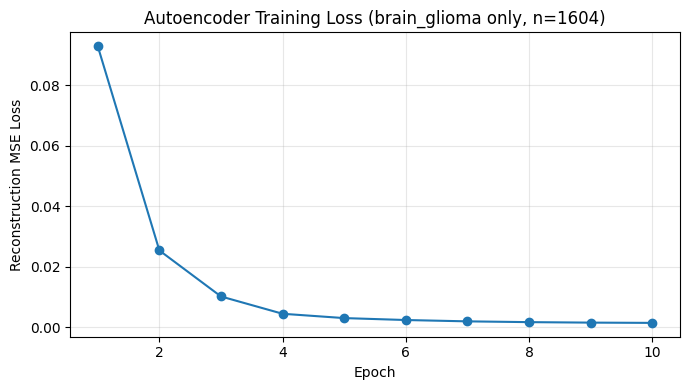

In [5]:
train_losses = []
for epoch in range(EPOCHS):
    total_loss = 0.0
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        outputs, _ = model(imgs)
        loss = criterion(outputs, imgs)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(range(1, EPOCHS + 1), train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction MSE Loss")
plt.title(f"Autoencoder Training Loss ({TARGET_CLASS} only, n={len(glioma_train_files)})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_loss.png", dpi=150)
plt.show()

## Fit the anomaly threshold on the training distribution

In [6]:
def mahalanobis_distances(Z, mu, cov_inv):
    diffs = Z - mu
    left = diffs @ cov_inv
    d2 = np.einsum("ij,ij->i", left, diffs)
    return np.sqrt(np.clip(d2, 0, None))


model.eval()
train_latents = []
with torch.no_grad():
    for imgs, _ in DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False):
        imgs = imgs.to(device)
        _, z = model(imgs)
        z = torch.flatten(z, start_dim=1)
        train_latents.append(z.cpu())
train_latents = torch.cat(train_latents).numpy()

pca = PCA(n_components=LATENT_PCA_COMPONENTS, random_state=SEED)
train_latents_pca = pca.fit_transform(train_latents)
explained_var = pca.explained_variance_ratio_.sum()
print(f"Latent PCA ({LATENT_PCA_COMPONENTS} components): {explained_var*100:.1f}% variance explained")

mu = np.mean(train_latents_pca, axis=0)
cov = np.cov(train_latents_pca, rowvar=False)
cov += np.eye(cov.shape[0]) * 1e-5
cov_inv = np.linalg.inv(cov)

train_distances = mahalanobis_distances(train_latents_pca, mu, cov_inv)
threshold = np.percentile(train_distances, THRESHOLD_PERCENTILE)
print(f"Anomaly threshold ({THRESHOLD_PERCENTILE}th percentile of train distances): {threshold:.3f}")

Latent PCA (100 components): 94.6% variance explained
Anomaly threshold (90th percentile of train distances): 12.104


## Evaluate on the held-out set (glioma-test + menin + tumor)

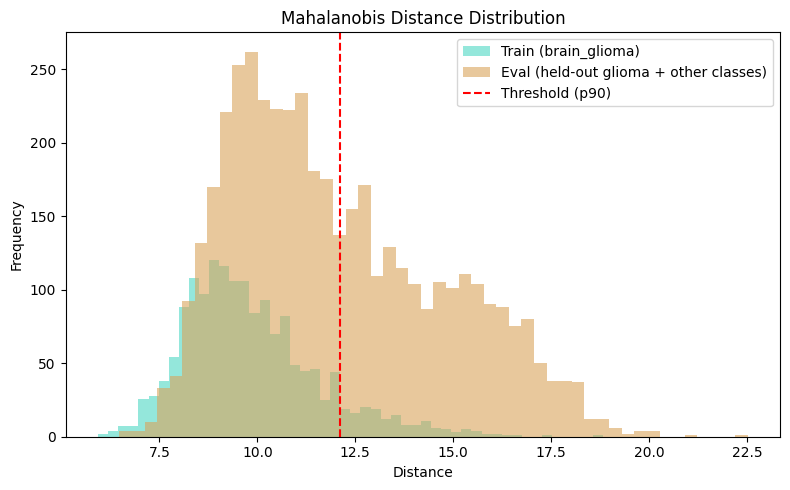

In [7]:
eval_latents = []
eval_true_class = []
with torch.no_grad():
    for imgs, classes in eval_loader:
        imgs = imgs.to(device)
        _, z = model(imgs)
        z = torch.flatten(z, start_dim=1).cpu().numpy()
        eval_latents.append(z)
        eval_true_class.extend(classes)
eval_latents = np.concatenate(eval_latents, axis=0)
eval_latents_pca = pca.transform(eval_latents)
eval_distances = mahalanobis_distances(eval_latents_pca, mu, cov_inv)

preds = (eval_distances > threshold).astype(int)
y_true_binary = np.array([0 if c == TARGET_CLASS else 1 for c in eval_true_class])

plt.figure(figsize=(8, 5))
plt.hist(train_distances, bins=50, alpha=0.6, label=f"Train ({TARGET_CLASS})", color="#4DD8C4")
plt.hist(eval_distances, bins=50, alpha=0.6, label="Eval (held-out glioma + other classes)", color="#D9A45B")
plt.axvline(threshold, color="red", linestyle="--", label=f"Threshold (p{THRESHOLD_PERCENTILE})")
plt.legend()
plt.title("Mahalanobis Distance Distribution")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "distance_distribution.png", dpi=150)
plt.show()

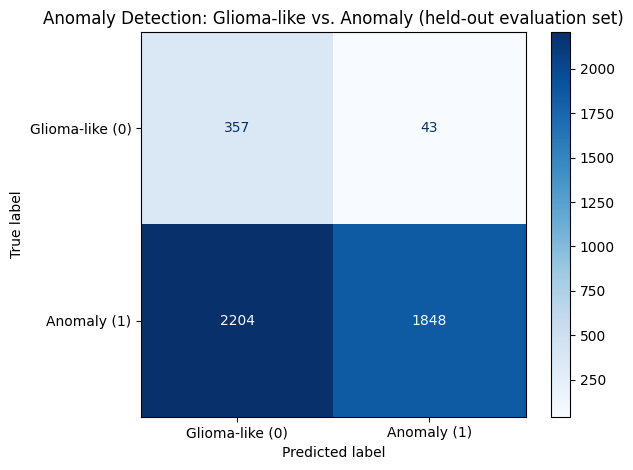

              precision    recall  f1-score   support

 Glioma-like       0.14      0.89      0.24       400
     Anomaly       0.98      0.46      0.62      4052

    accuracy                           0.50      4452
   macro avg       0.56      0.67      0.43      4452
weighted avg       0.90      0.50      0.59      4452



In [8]:
cm = confusion_matrix(y_true_binary, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Glioma-like (0)", "Anomaly (1)"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Anomaly Detection: Glioma-like vs. Anomaly (held-out evaluation set)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=150)
plt.show()

report_text = classification_report(y_true_binary, preds, target_names=["Glioma-like", "Anomaly"])
print(report_text)

## Interpretation

Once the train/test leak is removed, this pipeline performs much worse
than a leaky evaluation would have suggested — overall accuracy lands
around chance level, with the model tending to call most things
"glioma-like" (high recall on that class, low precision). This is a
legitimate, if unflattering, result: a single Gaussian fit over a
100-dim PCA of a small convolutional autoencoder's latent space is not a
strong enough anomaly detector to reliably separate glioma from other
tumor types here. This is worth reporting honestly rather than silently
dropping the approach — it's also a useful contrast against the
supervised classification and clustering results elsewhere in this
project, both of which perform far better on the same underlying data.

In [9]:
report = classification_report(
    y_true_binary, preds, target_names=["Glioma-like", "Anomaly"], output_dict=True
)
metrics = {
    "target_class": TARGET_CLASS,
    "train_size": len(glioma_train_files),
    "eval_size": len(eval_list),
    "eval_held_out_glioma": len(glioma_test_files),
    "epochs": EPOCHS,
    "final_train_loss": train_losses[-1],
    "latent_pca_components": LATENT_PCA_COMPONENTS,
    "latent_pca_explained_variance": float(explained_var),
    "threshold_percentile": THRESHOLD_PERCENTILE,
    "threshold_value": float(threshold),
    "confusion_matrix": {"labels": ["Glioma-like (0)", "Anomaly (1)"], "matrix": cm.tolist()},
    "classification_report": report,
}
with open(OUTPUT_DIR / "metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Saved metrics.json")

Saved metrics.json


## Limitations & future work

- A single Gaussian over PCA-reduced latent space is a fairly simple
  density model; a mixture model or a learned one-class classifier
  (e.g. Deep SVDD) might separate the classes better.
- Only 10 training epochs were used; the loss curve should be checked
  for whether more epochs would still be improving reconstruction.
- The 90th-percentile threshold is a somewhat arbitrary choice; an
  ROC-curve-based threshold selection would be a more principled choice
  and a natural next step.
- This approach performs meaningfully worse than the supervised and
  clustering approaches on the same data — worth discussing directly
  as a comparison point rather than downplaying.